In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from statespacecheck_paper.load_local_data import load_neural_recording_from_files
from statespacecheck_paper.real_data_analysis import (
    compute_model_diagnostics,
    create_decoder_environment,
    extract_place_fields,
    fit_decoder_models,
    get_spike_counts,
)
from statespacecheck_paper.real_data_plotting import (
    plot_metric_distributions,
    plot_metrics_time_vs_position_comparison,
    plot_model_comparison_with_posterior,
    plot_track_graph_2d,
)
from statespacecheck_paper.style import save_figure, set_figure_defaults

# Check for optional decoder dependencies
try:
    DECODERS_AVAILABLE = True
except ImportError:
    DECODERS_AVAILABLE = False
    warnings.warn(
        "non_local_detector not available. Figure 4 requires fitted decoder models. "
        "Install with: pip install non_local_detector",
        stacklevel=2,
    )


# -----------------------------
# Configuration
# -----------------------------

DATA_PATH = Path("../data")
ANIMAL_DATE_EPOCH = "j1620210710_02_r1"

# Time window for Figure 4a (index into decoded results)
FIGURE_4A_WINDOW_CENTER = 177301  # Time index around which to show detail
FIGURE_4A_WINDOW_HALF_WIDTH = 100  # Half-width in time points

/Users/edeno/Documents/GitHub/statespacecheck-paper/.venv/lib/python3.11/site-packages/non_local_detector/likelihoods/clusterless_gmm.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # type: ignore[import-untyped]


In [2]:
print("Loading data...")
data = load_neural_recording_from_files(DATA_PATH, ANIMAL_DATE_EPOCH)
print(f"  Loaded {len(data['spike_times'])} cells")

# Create environment
env = create_decoder_environment(
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
)

# Prepare training data
position_info = data["position_info"]
time = position_info.index.values
position = position_info[["head_position_x", "head_position_y"]].values
linear_position = position_info["linear_position"].values
spike_times_list: list[Any] = list(data["spike_times"])

# Fit models
print("Fitting models...")
continuous_model, contfrag_model = fit_decoder_models(
    position=position,
    spike_times=spike_times_list,
    time=time,
    environment=env,
)

# Decode all time points
print(f"Decoding {len(time)} time points...")
from non_local_detector.continuous_state_transitions import RandomWalk

continuous_model.continuous_transition_types = [[RandomWalk(movement_var=0.1)]]

continuous_results = continuous_model.estimate_parameters(
    position_time=time,
    position=position,
    spike_times=spike_times_list,
    time=time,
    return_outputs=["filter", "predictive_posterior", "log_likelihood"],
)
contfrag_results = contfrag_model.estimate_parameters(
    position_time=time,
    position=position,
    spike_times=spike_times_list,
    time=time,
    return_outputs=["filter", "predictive_posterior", "log_likelihood"],
)

# Get spike counts for all time
spike_counts = get_spike_counts(spike_times_list, time)

Loading data...
  Loaded 203 cells
Fitting models...


Encoding models:   0%|          | 0/203 [00:00<?, ?cell/s]

Encoding models:   0%|          | 0/203 [00:00<?, ?cell/s]

Decoding 709321 time points...


Encoding models:   0%|          | 0/203 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/203 [00:00<?, ?cell/s]

/Users/edeno/Documents/GitHub/statespacecheck-paper/.venv/lib/python3.11/site-packages/jax/_src/interpreters/mlir.py:1280: UserWarning: Some donated buffers were not usable: float32[248].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Non-Local Likelihood:   0%|          | 0/203 [00:00<?, ?cell/s]

Encoding models:   0%|          | 0/203 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/203 [00:00<?, ?cell/s]

/Users/edeno/Documents/GitHub/statespacecheck-paper/.venv/lib/python3.11/site-packages/jax/_src/interpreters/mlir.py:1280: UserWarning: Some donated buffers were not usable: float32[496].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Non-Local Likelihood:   0%|          | 0/203 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/203 [00:00<?, ?cell/s]

In [3]:
# contfrag_model2 = contfrag_model.estimate_parameters(
#     spike_times=spike_times_list,
#     time=time,
#     return_outputs=[ "predictive_posterior"],
# )

In [4]:
continuous_model

,discrete_initial_conditions,"array([1.], dtype=float32)"
,continuous_initial_conditions_types,[UniformInitialConditions()]
,discrete_transition_type,DiscreteStati...s=array([1.]))
,discrete_transition_concentration,1.0
,discrete_transition_stickiness,array([0.])
,discrete_transition_regularization,1e-10
,continuous_transition_types,[[RandomWalk(en...irection=None)]]
,observation_models,[ObservationMo...o_spike=False)]
,environments,[Environment(e..._fitted=False)]
,sorted_spikes_algorithm,'sorted_spikes_kde'
,sorted_spikes_algorithm_params,"{'block_size': 10000, 'position_std': np.float64(3.5355339059327378)}"


In [5]:
continuous_results

<xarray.Dataset> Size: 3GB
Dimensions:                      (time: 709321, state_bins: 256, state_ind: 256)
Coordinates:
  * time                         (time) float64 6MB 1.626e+09 ... 1.626e+09
  * state_bins                   (state_bins) object 2kB MultiIndex
  * state_ind                    (state_ind) int64 2kB 0 0 0 0 0 0 ... 0 0 0 0 0
    states                       <U10 40B 'Continuous'
    environments                 <U1 4B ''
    encoding_groups              int64 8B 0
  * state                        (state_bins) object 2kB 'Continuous' ... 'Co...
  * position                     (state_bins) float64 2kB 0.9997 2.999 ... 607.5
Data variables:
    acausal_posterior            (time, state_bins) float32 726MB 0.0 ... 0.0
    acausal_state_probabilities  (time) float32 3MB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    log_likelihood               (time, state_bins) float32 726MB -8.874 ... ...
    causal_posterior             (time, state_bins) float32 726MB 0.0 ... 0.0
    causal_state_probabilities   (time) float32 3MB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    predictive_posterior         (time, state_bins) float32 726MB 0.0 ... 0.0
Attributes:
    marginal_log_likelihoods:  [-4310875.5 -4310870.5]

In [6]:
contfrag_results

<xarray.Dataset> Size: 6GB
Dimensions:                      (time: 709321, state_bins: 512, states: 2,
                                  state_ind: 512)
Coordinates:
  * time                         (time) float64 6MB 1.626e+09 ... 1.626e+09
  * state_bins                   (state_bins) object 4kB MultiIndex
  * states                       (states) <U10 80B 'Continuous' 'Fragmented'
  * state_ind                    (state_ind) int64 4kB 0 0 0 0 0 0 ... 1 1 1 1 1
    environments                 (states) <U1 8B '' ''
    encoding_groups              (states) int64 16B 0 0
  * state                        (state_bins) object 4kB 'Continuous' ... 'Fr...
  * position                     (state_bins) float64 4kB 0.9997 2.999 ... 607.5
Data variables:
    acausal_posterior            (time, state_bins) float32 1GB 0.0001011 ......
    acausal_state_probabilities  (time, states) float32 6MB 0.9994 ... 0.001413
    log_likelihood               (time, state_bins) float32 1GB -8.874 ... -1...
    causal_posterior             (time, state_bins) float32 1GB 0.001066 ... ...
    causal_state_probabilities   (time, states) float32 6MB 0.9895 ... 0.001413
    predictive_posterior         (time, state_bins) float32 1GB 0.0009119 ......
Attributes:
    marginal_log_likelihoods:  [-3671454.75 -3660992.25 -3660890.75]

In [7]:
results = continuous_results
model = continuous_model
predictive_posterior = results.predictive_posterior.dropna(dim="state_bins")

In [8]:
[obs for obs in contfrag_model.observation_models]

[ObservationModel(environment_name='', encoding_group=0, is_local=False, is_no_spike=False),
 ObservationModel(environment_name='', encoding_group=0, is_local=False, is_no_spike=False)]

In [9]:
place_fields = np.concatenate(
    [
        extract_place_fields(
            model,
            environment_name=obs.environment_name,
            encoding_group=obs.encoding_group,
        )[0]
        for obs in model.observation_models
    ],
    axis=1,
)  # shape (n_cells, n_bins)
place_fields = place_fields[:, model.is_track_interior_state_bins_]
place_fields.shape

(203, 248)

In [10]:
model.state_ind_[model.is_track_interior_state_bins_]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [11]:
# Compute diagnostics for all time
print("Computing diagnostics...")
continuous_diagnostics = compute_model_diagnostics(
    continuous_model, continuous_results, spike_counts, time
)
contfrag_diagnostics = compute_model_diagnostics(
    contfrag_model, contfrag_results, spike_counts, time
)

Computing diagnostics...


In [12]:
# Extract place fields to get peak positions for sorting raster
place_fields, position_bins = extract_place_fields(continuous_model)
place_field_peaks = position_bins[np.argmax(place_fields, axis=1)]

In [13]:
# Print summary (all time points)
print("\n=== Diagnostic Summary (all time points) ===")
for metric in ["hpd_overlap", "kl_divergence", "spike_prob"]:
    cont_mean = np.nanmean(continuous_diagnostics[metric])
    frag_mean = np.nanmean(contfrag_diagnostics[metric])
    print(f"{metric}:")
    print(f"  Continuous: {cont_mean:.4f}")
    print(f"  ContFrag:   {frag_mean:.4f}")


=== Diagnostic Summary (all time points) ===
hpd_overlap:
  Continuous: 0.8779
  ContFrag:   0.8405
kl_divergence:
  Continuous: 5.9128
  ContFrag:   3.5048
spike_prob:
  Continuous: 0.4935
  ContFrag:   0.5255



Generating Figure 4...


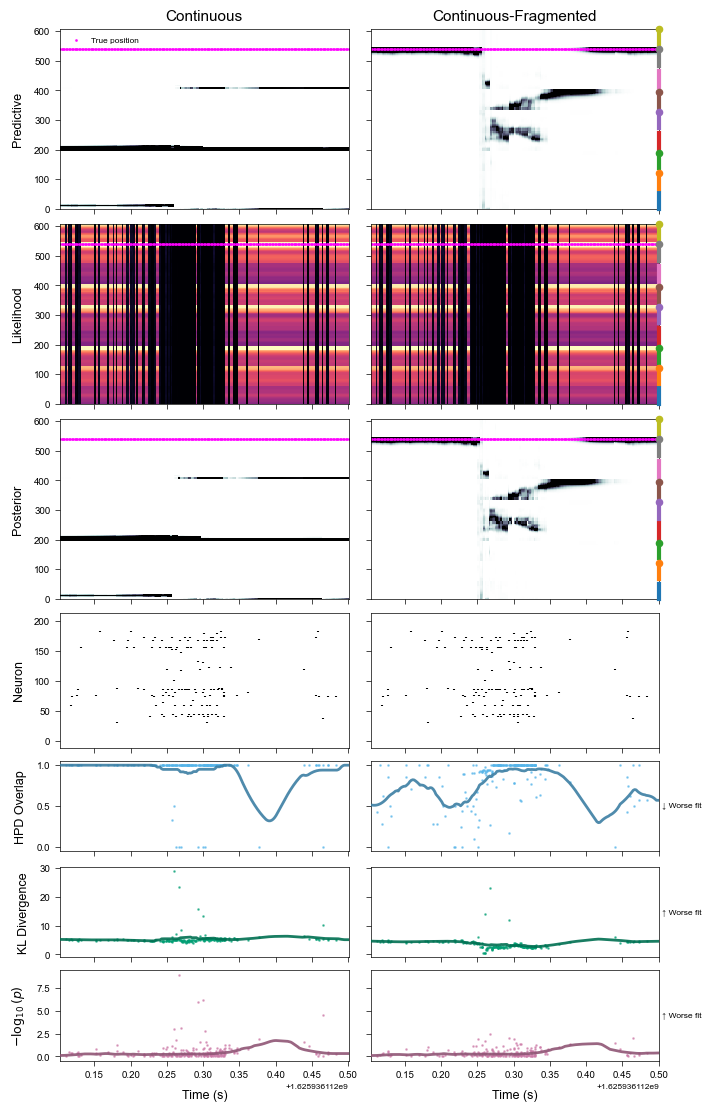

In [49]:
# Generate figures
print("\nGenerating Figure 4...")
set_figure_defaults()

# Define time slice for Figure 4a (detail view)
window_start = FIGURE_4A_WINDOW_CENTER - FIGURE_4A_WINDOW_HALF_WIDTH
window_end = FIGURE_4A_WINDOW_CENTER + FIGURE_4A_WINDOW_HALF_WIDTH
time_slice_ind = slice(window_start, window_end)

# Figure 4a: Model comparison with posterior, raster, and diagnostics (time window)
# should plot predictive posterior, likelihood, filter distribution?
fig, axes = plot_model_comparison_with_posterior(
    time,
    linear_position,
    continuous_results,
    contfrag_results,
    continuous_diagnostics,
    contfrag_diagnostics,
    spike_times=spike_times_list,
    place_field_peaks=place_field_peaks,
    time_slice_ind=time_slice_ind,
    model_a_name="Continuous",
    model_b_name="Continuous-Fragmented",
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
    show_running_average=True,
)

(0.0, 203.0)

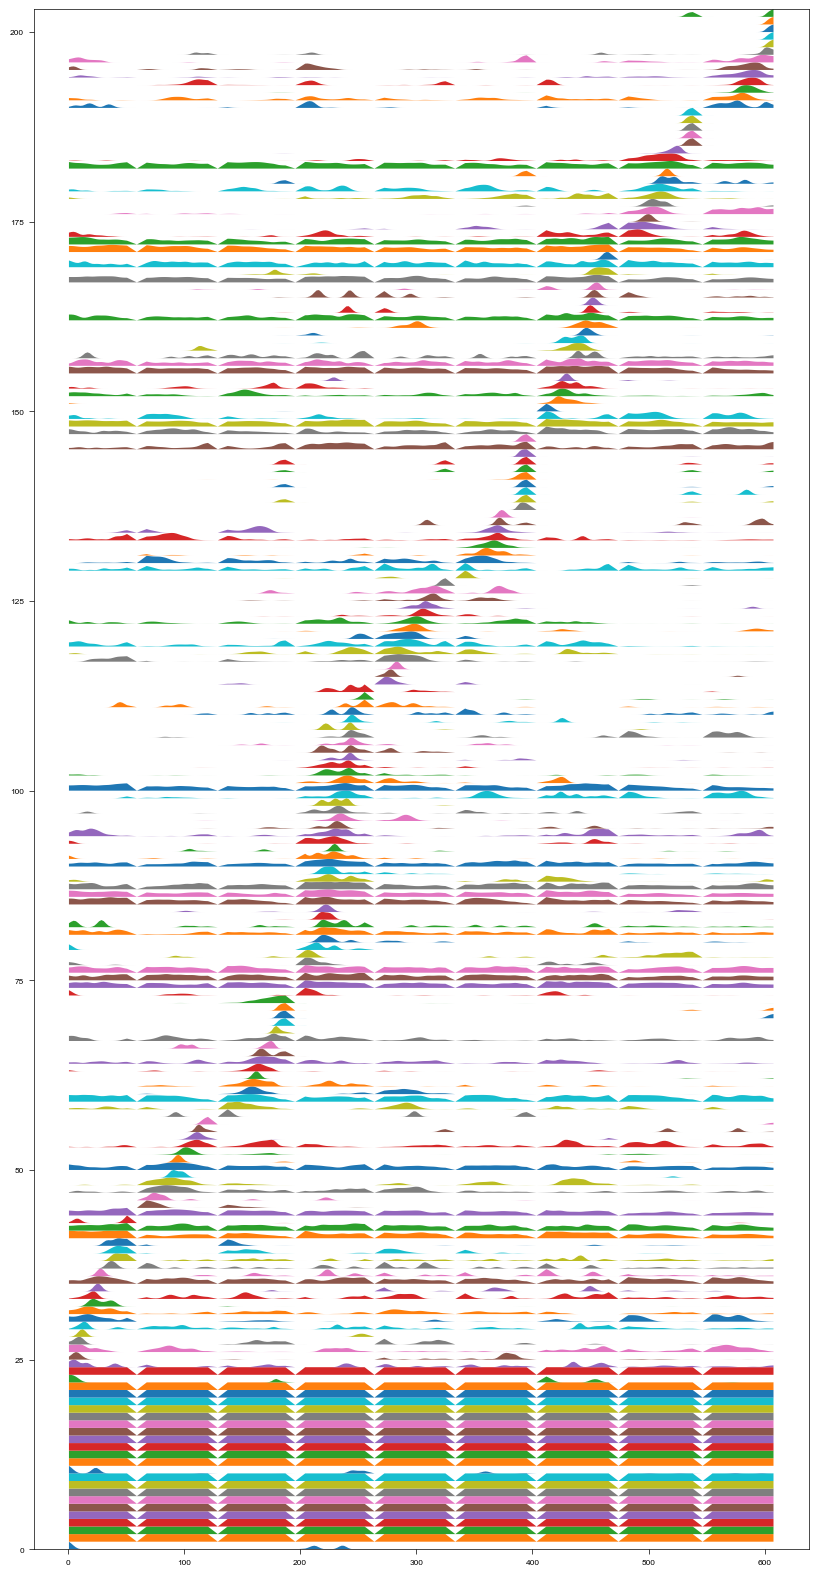

In [ ]:
place_fields = continuous_model.encoding_model_[("", 0)]["place_fields"]
fig, ax = plt.subplots(figsize=(10, 20))
place_field_peaks = np.argmax(place_fields, axis=1)
sorted_peaks = np.argsort(place_field_peaks)
for i, rate_map in enumerate(place_fields[sorted_peaks]):
    normalized = rate_map / (np.max(rate_map) - np.min(rate_map))
    ax.fill_between(
        continuous_model.environments[0].place_bin_centers_.squeeze(), i, normalized + i
    )

ax.set_ylim(0, place_fields.shape[0])

(0.0, 42.0)

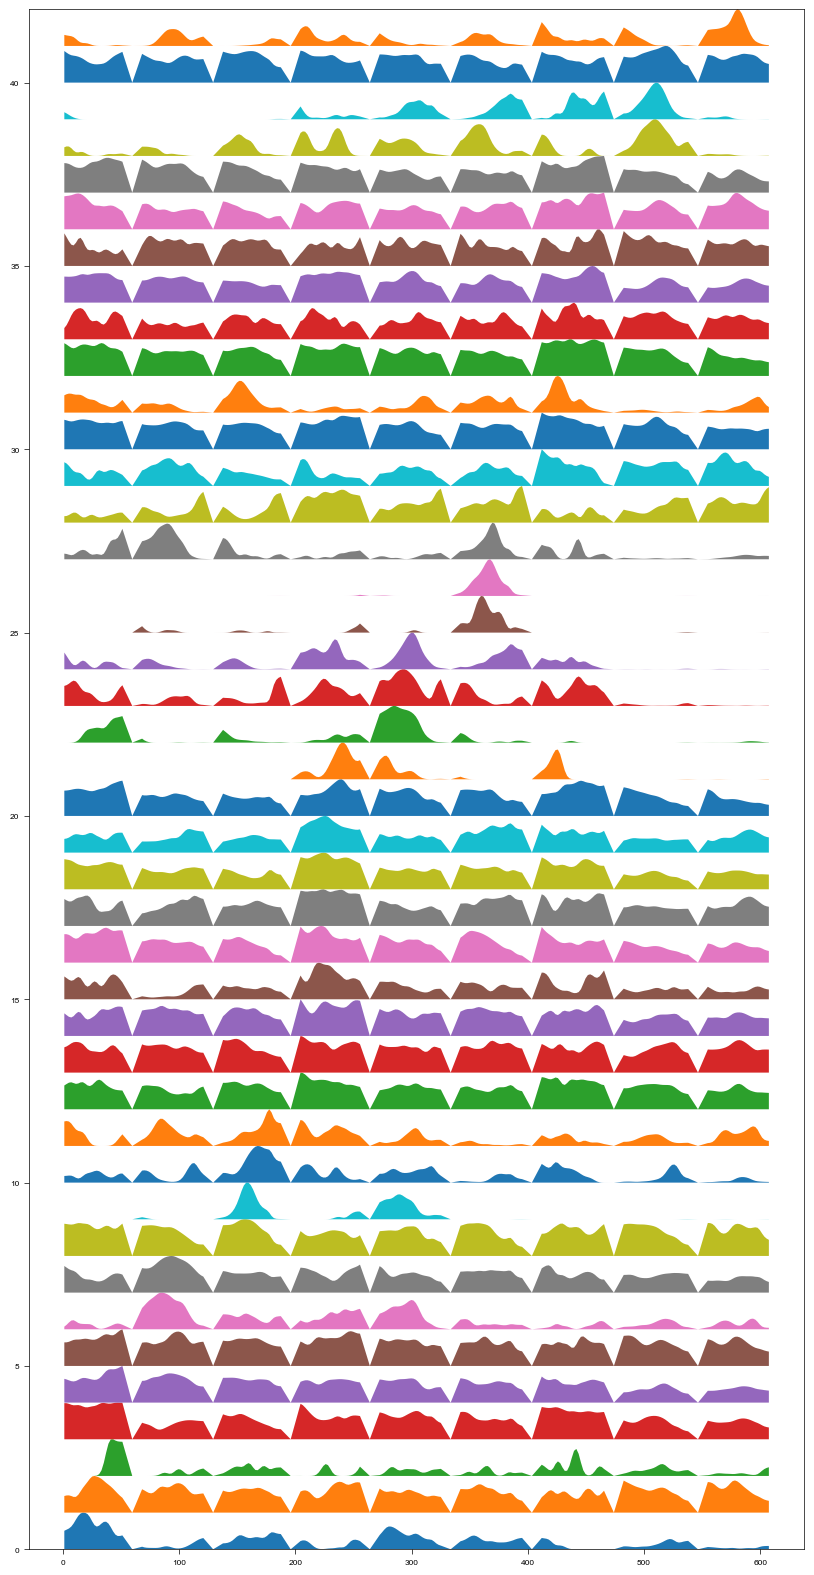

In [56]:
# cells that fire during this time window
t_start, t_end = time[time_slice_ind][[0, -1]]
has_spike_during_window = np.array(
    [
        np.any((neuron_spike_times >= t_start) & (neuron_spike_times <= t_end))
        for neuron_spike_times in spike_times_list
    ]
)


place_fields = continuous_model.encoding_model_[("", 0)]["place_fields"][has_spike_during_window]
fig, ax = plt.subplots(figsize=(10, 20))
place_field_peaks = np.argmax(place_fields, axis=1)
sorted_peaks = np.argsort(place_field_peaks)
for i, rate_map in enumerate(place_fields[sorted_peaks]):
    normalized = rate_map / (np.max(rate_map) - np.min(rate_map))
    ax.fill_between(
        continuous_model.environments[0].place_bin_centers_.squeeze(), i, normalized + i
    )

ax.set_ylim(0, place_fields.shape[0])


Generating Figure 4...


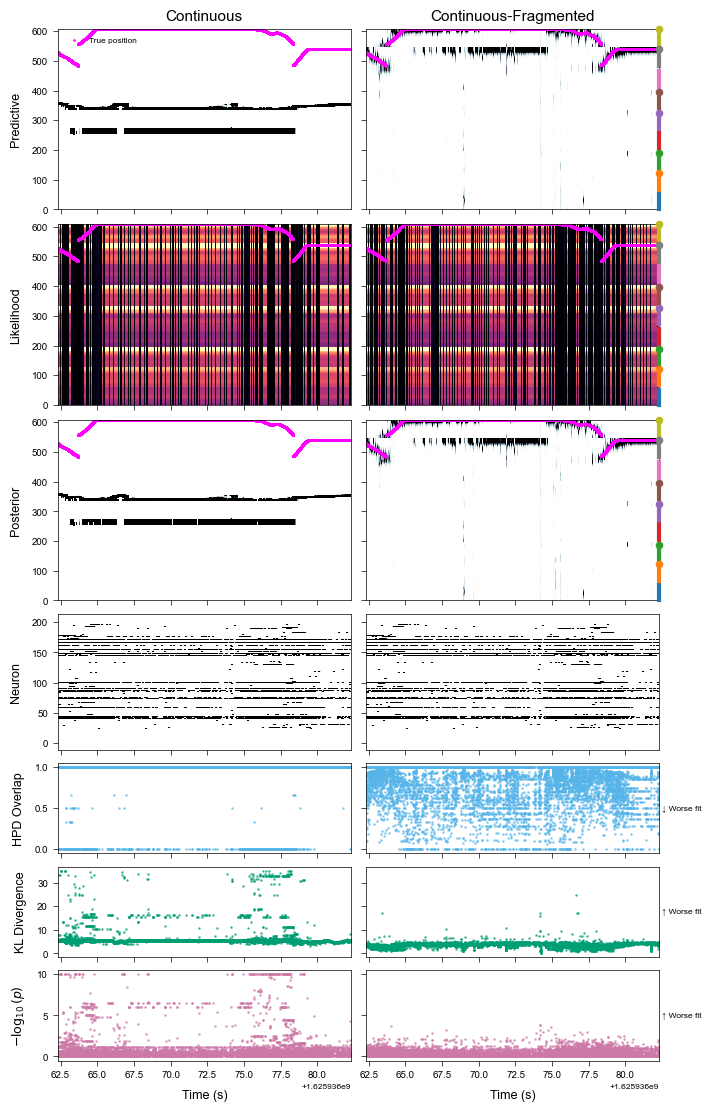

In [15]:
# Generate figures
print("\nGenerating Figure 4...")
set_figure_defaults()

# Define time slice for Figure 4a (detail view)
new_center = 157301
half_width = 5000
window_start = new_center - half_width
window_end = new_center + half_width
time_slice_ind = slice(window_start, window_end)

# Figure 4a: Model comparison with posterior, raster, and diagnostics (time window)
# should plot predictive posterior, likelihood, filter distribution?
fig, axes = plot_model_comparison_with_posterior(
    time,
    linear_position,
    continuous_results,
    contfrag_results,
    continuous_diagnostics,
    contfrag_diagnostics,
    spike_times=spike_times_list,
    place_field_peaks=place_field_peaks,
    time_slice_ind=time_slice_ind,
    model_a_name="Continuous",
    model_b_name="Continuous-Fragmented",
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
)


Generating Figure 4...


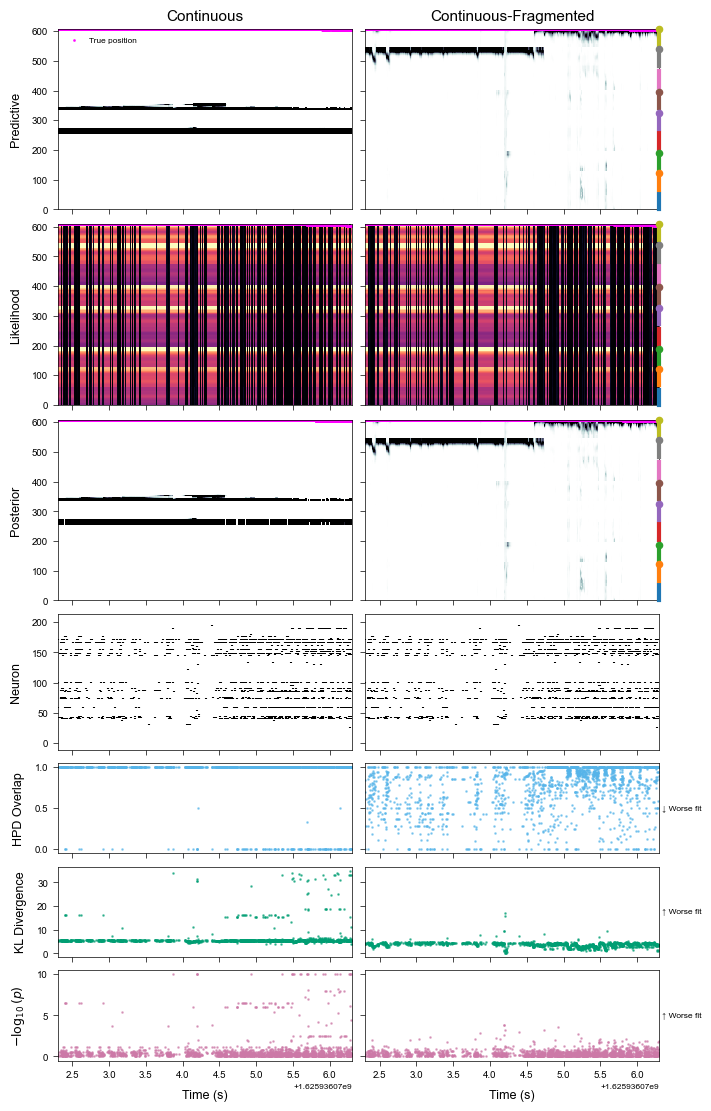

In [16]:
# Generate figures
print("\nGenerating Figure 4...")
set_figure_defaults()

# Define time slice for Figure 4a (detail view)
new_center = 158301
half_width = 1000
window_start = new_center - half_width
window_end = new_center + half_width
time_slice_ind = slice(window_start, window_end)

# Figure 4a: Model comparison with posterior, raster, and diagnostics (time window)
# should plot predictive posterior, likelihood, filter distribution?
fig, axes = plot_model_comparison_with_posterior(
    time,
    linear_position,
    continuous_results,
    contfrag_results,
    continuous_diagnostics,
    contfrag_diagnostics,
    spike_times=spike_times_list,
    place_field_peaks=place_field_peaks,
    time_slice_ind=time_slice_ind,
    model_a_name="Continuous",
    model_b_name="Continuous-Fragmented",
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
)


Generating Figure 4...


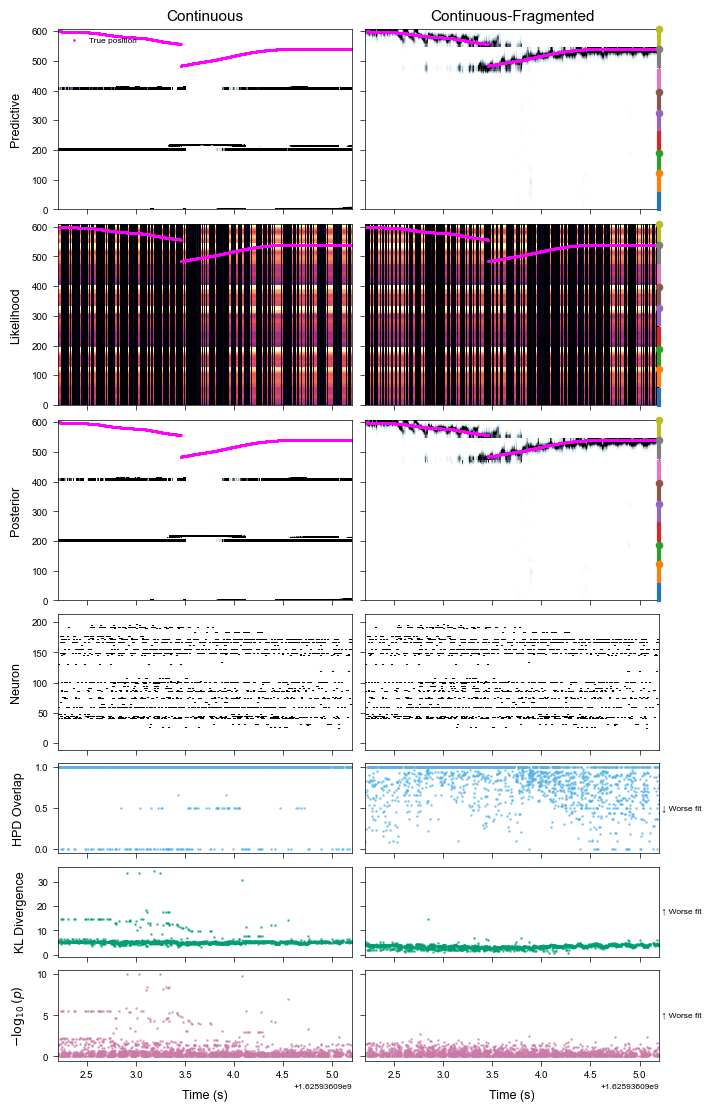

In [17]:
# Generate figures
print("\nGenerating Figure 4...")
set_figure_defaults()

# Define time slice for Figure 4a (detail view)
new_center = 168001
half_width = 750
window_start = new_center - half_width
window_end = new_center + half_width
time_slice_ind = slice(window_start, window_end)

# Figure 4a: Model comparison with posterior, raster, and diagnostics (time window)
# should plot predictive posterior, likelihood, filter distribution?
fig, axes = plot_model_comparison_with_posterior(
    time,
    linear_position,
    continuous_results,
    contfrag_results,
    continuous_diagnostics,
    contfrag_diagnostics,
    spike_times=spike_times_list,
    place_field_peaks=place_field_peaks,
    time_slice_ind=time_slice_ind,
    model_a_name="Continuous",
    model_b_name="Continuous-Fragmented",
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
)

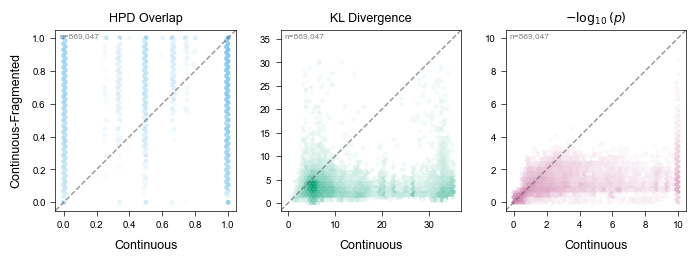

In [18]:
fig, axes = plot_metric_distributions(
    continuous_diagnostics,
    contfrag_diagnostics,
    model_a_name="Continuous",
    model_b_name="Continuous-Fragmented",
)

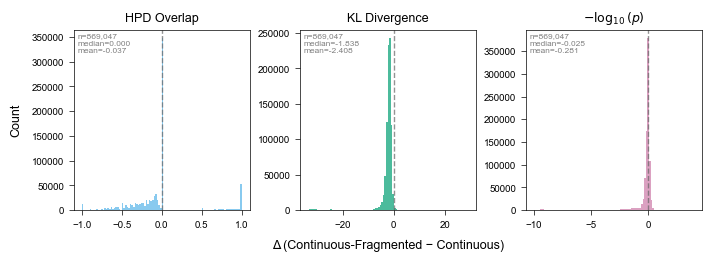

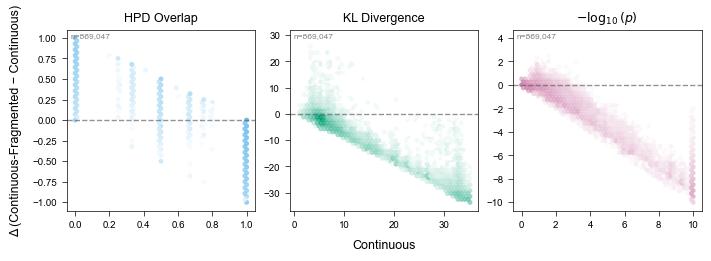

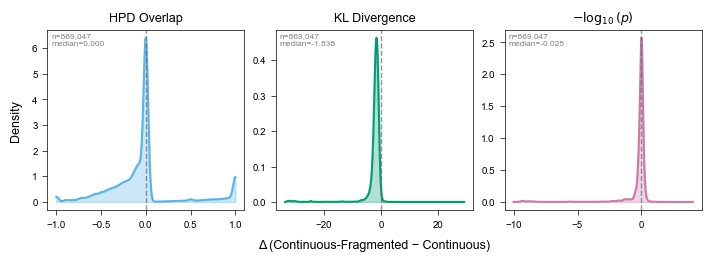

In [19]:
from statespacecheck_paper.real_data_plotting import (
    plot_metric_diff_hexbin,
    plot_metric_diff_histogram,
    plot_metric_diff_kde,
)

fig, axes = plot_metric_diff_histogram(continuous_diagnostics, contfrag_diagnostics)
fig, axes = plot_metric_diff_hexbin(continuous_diagnostics, contfrag_diagnostics)
fig, axes = plot_metric_diff_kde(continuous_diagnostics, contfrag_diagnostics)

In [20]:
fig, axes = plot_metrics_time_vs_position_comparison(
    linear_position,
    continuous_diagnostics,
    contfrag_diagnostics,
    model_a_name="Continuous",
    model_b_name="Cont-Frag",
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
)

TypeError: plot_metrics_time_vs_position_comparison() got an unexpected keyword argument 'model_a_name'

In [ ]:
continuous_results

In [ ]:
contfrag_results.predictive_posterior

In [ ]:
np.nonzero(spike_counts)[0][:10]

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

time_ind = 2
axes[0].plot(np.exp(continuous_results.log_likelihood.isel(time=time_ind)))
axes[1].plot(continuous_results.predictive_posterior.isel(time=time_ind))
axes[2].plot(continuous_results.causal_posterior.isel(time=time_ind))

In [ ]:
from statespacecheck_paper.real_data_plotting import (
    plot_metrics_time_vs_position_comparison,
)

fig, axes = plot_metrics_time_vs_position_comparison(
    linear_position,
    continuous_diagnostics,
    contfrag_diagnostics,
    model_a_name="Continuous",
    model_b_name="Cont-Frag",
    track_graph=data["track_graph"],
    edge_order=data["linear_edge_order"],
    edge_spacing=data["linear_edge_spacing"],
)